In [ ]:
#Load Dataset
import pandas as pd
df=pd.read_excel("/content/Online Retail.xlsx");
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#Understand the data
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
#check missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#Remove Duplicate rules
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
#Handel missing values
df.drop(columns='Description',inplace=True)
df.drop(columns='CustomerID',inplace=True)

In [ ]:
#Convert data
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

,0
InvoiceNo,object
StockCode,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
Country,object


In [ ]:
#Create Date Features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Weekday"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

In [ ]:
#Remove negative quantities
df=df[df['Quantity']>0]

In [ ]:
#Remove negative or zero prices
df=df[df['UnitPrice']>0]

In [ ]:
#remove cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [ ]:
#Create sales columns
df["Sales"] = df["Quantity"] * df["UnitPrice"]

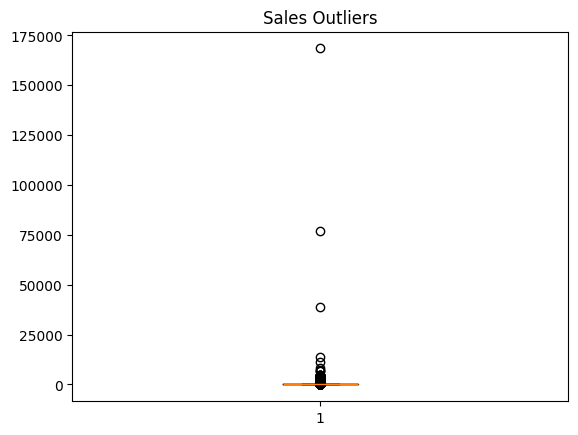

In [ ]:
#Check outliers
import matplotlib.pyplot as plt

plt.boxplot(df["Sales"])
plt.title("Sales Outliers")
plt.show()

In [ ]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]

print(outliers.shape)

(42624, 12)


In [ ]:
#Final check
df.info()

df.isnull().sum()

df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Quantity     524878 non-null  int64         
 3   InvoiceDate  524878 non-null  datetime64[ns]
 4   UnitPrice    524878 non-null  float64       
 5   Country      524878 non-null  object        
 6   Year         524878 non-null  int32         
 7   Month        524878 non-null  int32         
 8   Day          524878 non-null  int32         
 9   Weekday      524878 non-null  object        
 10  Hour         524878 non-null  int32         
 11  Sales        524878 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(4), int64(1), object(4)
memory usage: 44.0+ MB


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,Country,Year,Month,Day,Weekday,Hour,Sales
0,536365,85123A,6,2010-12-01 08:26:00,2.55,United Kingdom,2010,12,1,Wednesday,8,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,United Kingdom,2010,12,1,Wednesday,8,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,United Kingdom,2010,12,1,Wednesday,8,20.34
